In [ ]:
#Importing packages
from torch.utils.data import DataLoader
import torch
import torch.optim as optim
import torch.nn as nn
from tqdm import tqdm
import pandas as pd
from chromadb import PersistentClient as PersistentClient
from chromadb.errors import InternalError as CollectionError

#library functions
import src.dataloading as dataloading
import src.data_vis as data_vis
import src.model_functions as model_functions
import src.loss_functions as loss_functions
import src.models as models
from src.seeds import set_seed


d:\Projects\alertcalifornia-anomaly-detection\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
g = set_seed()

In [3]:
labels_csv = r"camera_data/all_data_4pt.csv"

device = 'cuda'

model_path = 'weights/'
model_name = "final_model.pth"

data = dataloading.get_data(labels_csv, 'camera_data/images/', replace_images = False, binarize=True)
train, val, test = dataloading.get_train_val_test(data = data, output_csvs=True)
train_dataloader, val_dataloader, test_dataloader = dataloading.get_train_val_test_dataloaders(train, val, test, generator = g)

100%|██████████| 6270/6270 [00:01<00:00, 4647.14it/s]


Instantiating the pre-trained model

In [4]:
encoder = models.create_encoder()
encoder.to(device)
encoder.load_state_dict(torch.load('weights/model_weights_camera_10-27-25.pth', map_location=device, weights_only=True));

Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Instantiating the training settings

In [5]:
loss_func = loss_functions.TripletMarginLoss(margin = 0.19)
optimizer = optim.Adam(encoder.parameters(), lr=1e-5) 
num_epochs = 10

Training the model

In [6]:
losses = model_functions.train_model(encoder, train_data=train_dataloader, 
                                num_epochs=num_epochs, loss_func=loss_func, 
                                optimizer=optimizer, name = model_name, 
                                path = 'weights/', device=device)

Processing batch 117 in epoch 0: : 118it [01:43,  1.14it/s]
Processing batch 117 in epoch 1: : 118it [01:43,  1.14it/s]
Processing batch 117 in epoch 2: : 118it [01:43,  1.14it/s]
Processing batch 117 in epoch 3: : 118it [01:43,  1.14it/s]
Processing batch 117 in epoch 4: : 118it [01:43,  1.14it/s]
Processing batch 117 in epoch 5: : 118it [01:42,  1.15it/s]
Processing batch 117 in epoch 6: : 118it [01:42,  1.15it/s]
Processing batch 117 in epoch 7: : 118it [01:43,  1.14it/s]
Processing batch 117 in epoch 8: : 118it [01:42,  1.15it/s]
Processing batch 117 in epoch 9: : 118it [01:42,  1.15it/s]


Saving the embeddings generated by this model

In [8]:
client = PersistentClient(path="embedding_data/") 

try:
    client.delete_collection(name="train_embeddings")
except Exception:
    pass

try:
    client.delete_collection(name="test_embeddings")
except Exception:
    pass


dataloading.save_full_embeddings(encoder, train_dataloader, 
                        "train_embeddings", persist_directory = "embedding_data/", 
                        device = device)


dataloading.save_full_embeddings(encoder, test_dataloader, 
                        "test_embeddings", persist_directory = "embedding_data/", 
                        device = device)
    
    
#Embeddings of training data, used to train the classification head
train_embeddings, train_labels, train_img_urls, train_a_ids = dataloading.load_full_embeddings(train, "train_embeddings", persist_directory = "embedding_data/")
train_embedding_dataloader = dataloading.embedding_to_dataloader(train_embeddings, train_labels, batch_size=32, generator = g)

#Embeddings of validation data, used to display results
test_embeddings, test_labels, test_img_urls, test_a_ids = dataloading.load_full_embeddings(test, "test_embeddings", persist_directory = "embedding_data/")

Visualizing the first two principal axes of the embedding space

In [9]:
reduced_embeddings, labels = model_functions.reduce_pca(train_embeddings, train_labels, dimensions=10)

#idx = (labels == 3).to_numpy()
#reduced_embeddings = reduced_embeddings[idx]
#labels = labels[idx]

In [46]:
pd.DataFrame(reduced_embeddings).to_csv("camera_data/reduced_embeddings_final.csv", index=False)

In [51]:
train_camera_locations = train_img_urls.str.extract(r'Axis-(\w+)/', expand=False)
test_camera_locations = test_img_urls.str.extract(r'Axis-(\w+)/', expand=False)

In [49]:
pd.DataFrame({"labels": train_labels, 
              "img_urls": train_img_urls, 
              "ids": train_a_ids, 
              "camera_locations": train_camera_locations}).to_csv("camera_data/labels_final.csv", index=False)

In [50]:
pd.Series(labels).value_counts()

label
0    2845
1     916
Name: count, dtype: int64

Text(0.5, 1.0, 'First two axes of embedding space for final model')

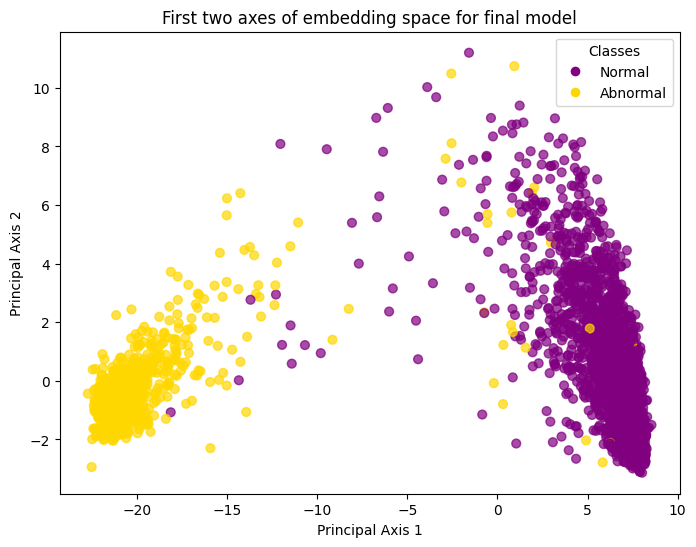

In [59]:
fig, ax = plt.subplots(figsize=(8, 6))
ax = data_vis.plot_data(reduced_embeddings, labels, pcx = 1, pcy = 2, ax=ax)
ax.set_title("First two axes of embedding space for final model")

Training classification head

In [14]:
losses = []

classification_head = models.ClassificationHead(num_classes=2)
classification_head.to(device)

head_criterion = nn.CrossEntropyLoss()
head_optimizer = optim.Adam(classification_head.parameters(), lr=1e-3) # Optimize only the new head

losses = model_functions.train_classification_head(classification_head, train_embedding_dataloader, num_epochs=10, criterion=head_criterion, optimizer=head_optimizer, 
                           device=device, model_name=model_name, model_path = "weights/", save=True)

#Report training and validation accuracy
classification_head.eval()

Processing batches in epoch 9: 100%|██████████| 118/118 [00:23<00:00,  4.92it/s]


ClassificationHead(
  (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (head): Sequential(
    (0): Linear(in_features=768, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=2, bias=True)
  )
)

Testing classification head outputs

In [53]:
#Function to calculate accuracy of classification head on given embeddings and labels
def get_accuracy(outputs, labels):
    return (torch.argmax(outputs, dim = -1) == labels).float().mean().item()


train_embeddings_tensor = torch.Tensor(train_embeddings.to_numpy()).to(device)
test_embeddings_tensor = torch.Tensor(test_embeddings.to_numpy()).to(device)

train_labels_tensor = torch.Tensor(train_labels.to_numpy()).to(device)
test_labels_tensor = torch.Tensor(test_labels.to_numpy()).to(device)


train_outputs = classification_head(train_embeddings_tensor)
test_outputs = classification_head(test_embeddings_tensor)

print(f"Training accuracy: {get_accuracy(train_outputs, train_labels_tensor)}")
print(f"Test accuracy: {get_accuracy(test_outputs, test_labels_tensor)}")

Training accuracy: 0.9962776303291321
Test accuracy: 0.939393937587738


In [55]:
for location in train_camera_locations.unique():
    train_idx = (train_camera_locations == location).to_numpy()
    test_idx = (test_camera_locations == location).to_numpy()

    location_train_outputs = classification_head(train_embeddings_tensor[train_idx])
    location_train_labels = train_labels_tensor[train_idx]

    location_test_outputs = classification_head(test_embeddings_tensor[test_idx])
    location_test_labels = test_labels_tensor[test_idx]

    location_train_acc = get_accuracy(location_train_outputs, location_train_labels)
    location_test_acc = get_accuracy(location_test_outputs, location_test_labels)
    
    print(f"Camera location: {location}")
    print(f"Training accuracy: {location_train_acc}")
    print(f"Test accuracy: {location_test_acc}")
    print("\n")

Camera location: MesaGrandeNorth
Training accuracy: 0.9946236610412598
Test accuracy: 0.9751861095428467


Camera location: PalomarObs1
Training accuracy: 1.0
Test accuracy: 0.9407583475112915


Camera location: CoronadoHillsS
Training accuracy: 0.9943937659263611
Test accuracy: 0.9044288992881775




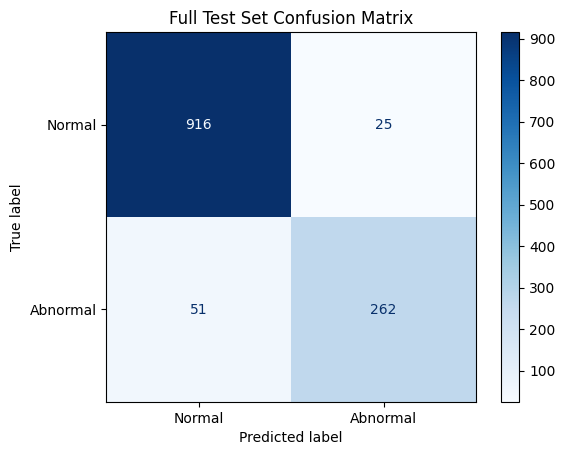

Recall: 0.8371
Precision: 0.9129


In [58]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrix(true_labels, pred_labels, title):
    cm = confusion_matrix(true_labels, pred_labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Abnormal"])
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

    recall = cm[1, 1] / (cm[1, 0] + cm[1, 1]) if (cm[1, 0] + cm[1, 1]) > 0 else 0
    precision = cm[1, 1] / (cm[0, 1] + cm[1, 1]) if (cm[0, 1] + cm[1, 1]) > 0 else 0
    print(f"Recall: {recall:.4f}")  
    print(f"Precision: {precision:.4f}")

plot_confusion_matrix(test_labels_tensor.cpu(), torch.argmax(test_outputs, dim=-1).cpu(), title="Full Test Set Confusion Matrix")